# PyKoopman: Appended Trajectories

> We use our training data to fit a DMD model by using time embeddings and multiple trajectories.

#### Imports

In [1]:
from ast import literal_eval

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from pydmd import DMD
from safetensors.torch import load_file

from learningdynamics.utils import safetensors_metadata_parser
from learningdynamics.dmd_dataset import (
    reshape_append_time,
    reshape_append_state,
    reshape_interleave_time,
)

In [2]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

The data is stored in 2D [states x length]

each block in the second dimension corresponds to a step for the n_traj

In [3]:
file_path = "../saved_weights/states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_LOOP_ITERATIONS = literal_eval(metadata["NUM_LOOP_ITERATIONS"])
NUM_TRAJECTORIES = literal_eval(metadata["NUM_TRAJECTORIES"])
NUM_STATES = literal_eval(metadata["NUM_STATES"])

data = load_file(file_path)

#### Update dataset

In [4]:
NUM_TRAJECTORIES = 2
NUM_LOOP_ITERATIONS = 25

NUM_DELAYS = int(NUM_LOOP_ITERATIONS * 0.7)
RANK = 50

#### Learn Koopman Operator

In [5]:
train_states = reshape_interleave_time(
    data["train_states"][:NUM_LOOP_ITERATIONS, :NUM_TRAJECTORIES, :]
)
test_states = reshape_interleave_time(
    data["test_states"][:NUM_LOOP_ITERATIONS, :NUM_TRAJECTORIES, :]
)
observables = pk.observables.TimeDelay(n_delays=NUM_DELAYS)

In [6]:
# Time shift data
X = train_states[:, :-1].numpy()
Y = train_states[:, 1:].numpy()

In [7]:
regressor = pk.regression.EDMD(svd_rank=RANK)
dmd_model = pk.Koopman(observables=observables, regressor=regressor)
dmd_model.fit(X.T, y=Y.T)

Koopman(observables=TimeDelay(n_delays=17), regressor=EDMD(svd_rank=50))

In [8]:
t = np.arange(0, NUM_LOOP_ITERATIONS, 1)

In [9]:
SAMPLE = 0

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)
/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: RuntimeWarning: overflow encountered in cast
  x = x.astype(self.A.dtype)


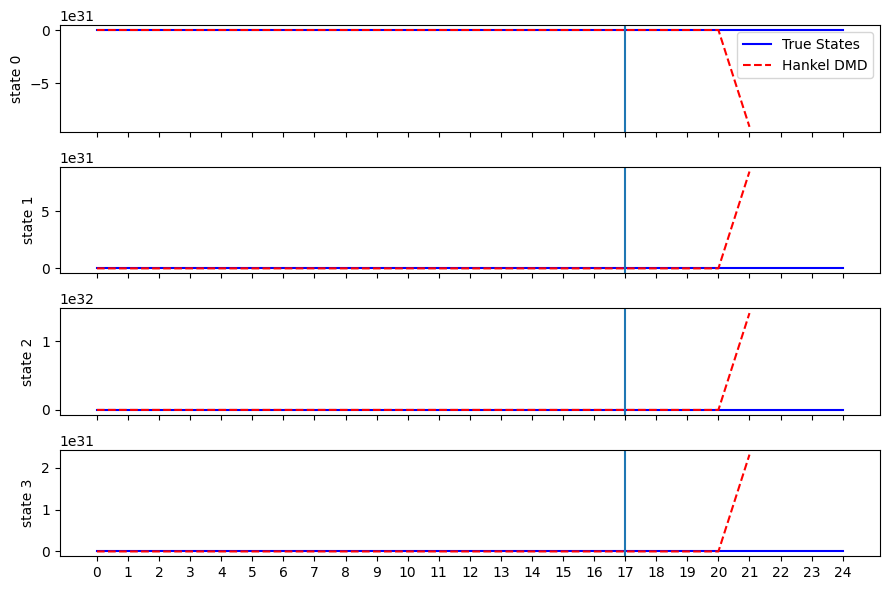

In [10]:
x0_td = train_states[:, SAMPLE::NUM_TRAJECTORIES][:, : NUM_DELAYS + 1].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - NUM_DELAYS - 1)
Xkoop = np.vstack([x0_td, Xkoop])

Xkoop.shape
fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 6))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t,
        train_states[state_idx, SAMPLE::NUM_TRAJECTORIES],
        "-",
        color="b",
        label="True States",
    )
    axs[state_idx].set_xticks(t)
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])

axs[0].legend()

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)
/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: RuntimeWarning: overflow encountered in cast
  x = x.astype(self.A.dtype)


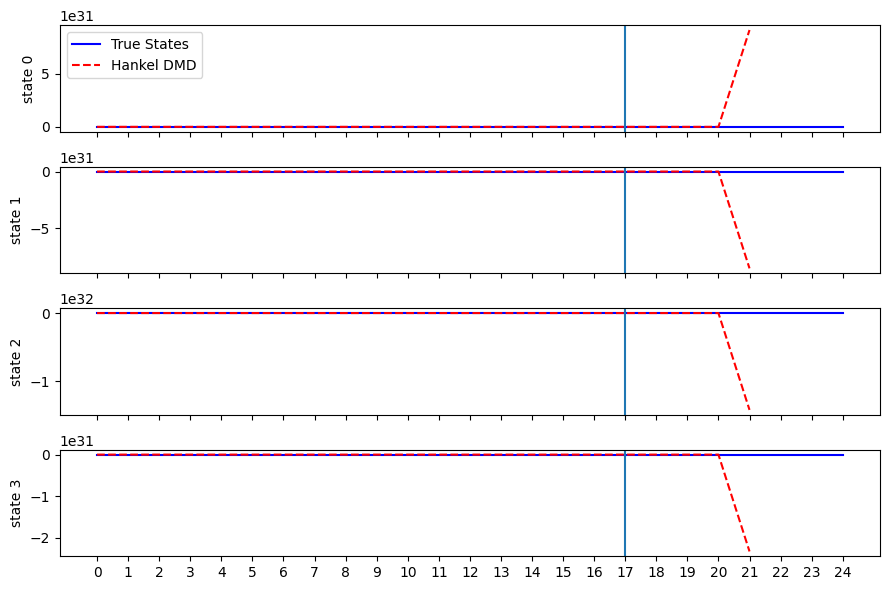

In [11]:
x0_td = test_states[:, SAMPLE::NUM_TRAJECTORIES][:, : NUM_DELAYS + 1].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - NUM_DELAYS - 1)
Xkoop = np.vstack([x0_td, Xkoop])

Xkoop.shape
fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 6))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t,
        test_states[state_idx, SAMPLE::NUM_TRAJECTORIES],
        "-",
        color="b",
        label="True States",
    )
    axs[state_idx].set_xticks(t)
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])

axs[0].legend()